<a href="https://colab.research.google.com/github/sudharsanaDA/lithub/blob/main/final_mp_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample Data:
   Rank                     Title  Year  Rating Duration  \
0     1  The Shawshank Redemption  1994     9.3   2h 22m   
1     2             The Godfather  1972     9.2   2h 55m   
2     3           The Dark Knight  2008     9.1   2h 32m   
3     4     The Godfather Part II  1974     9.0   3h 22m   
4     5              12 Angry Men  1957     9.0   1h 36m   

                                IMDb URL  \
0  https://www.imdb.com/title/tt0111161/   
1  https://www.imdb.com/title/tt0068646/   
2  https://www.imdb.com/title/tt0468569/   
3  https://www.imdb.com/title/tt0071562/   
4  https://www.imdb.com/title/tt0050083/   

                                           Image URL  
0  https://m.media-amazon.com/images/M/MV5BMDAyY2...  
1  https://m.media-amazon.com/images/M/MV5BNGEwYj...  
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...  
3  https://m.media-amazon.com/images/M/MV5BMDIxMz...  
4  https://m.media-amazon.com/images/M/MV5BYjE4Nz...  

Sample Extracted Entities:
   

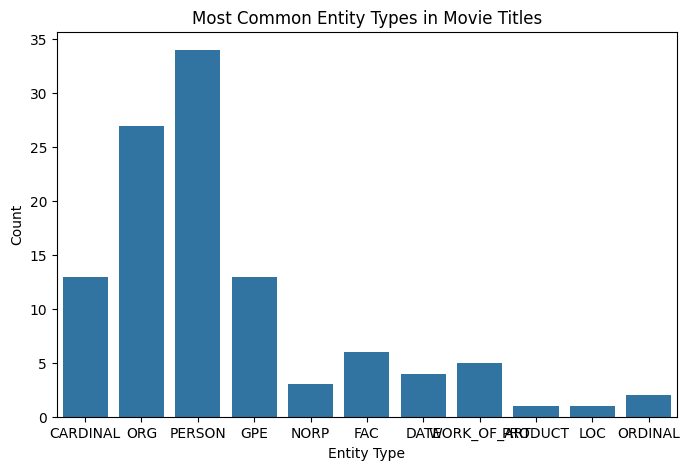


Top Mentioned Movies (from titles):
Love the Bomb: 1
The Chaos Class Failed the Class: 1
The Secret in Their Eyes: 1
Logan: 1
The Battle of Algiers: 1

Top Mentioned People (from titles):
Toy Story: 2
Demon Slayer: 2
Kimetsu: 2
Forrest Gump: 1
Goodfellas: 1
Prestige: 1
Django Unchained: 1
Inglourious Basterds: 1
Strangelove: 1
Joker: 1


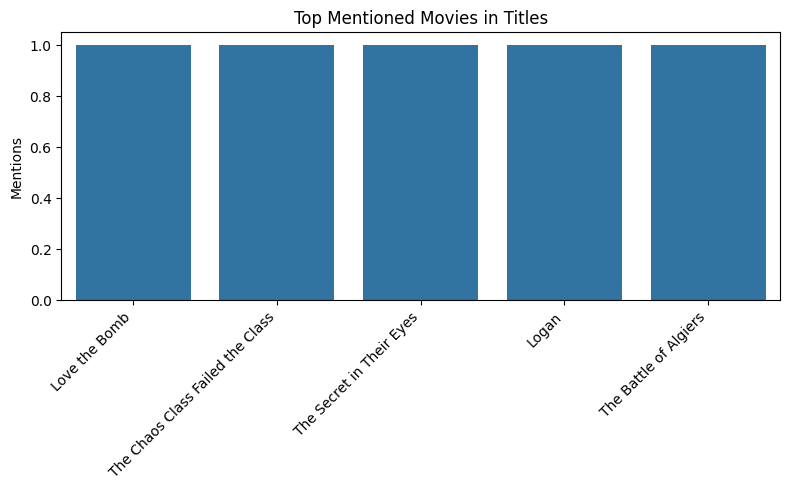

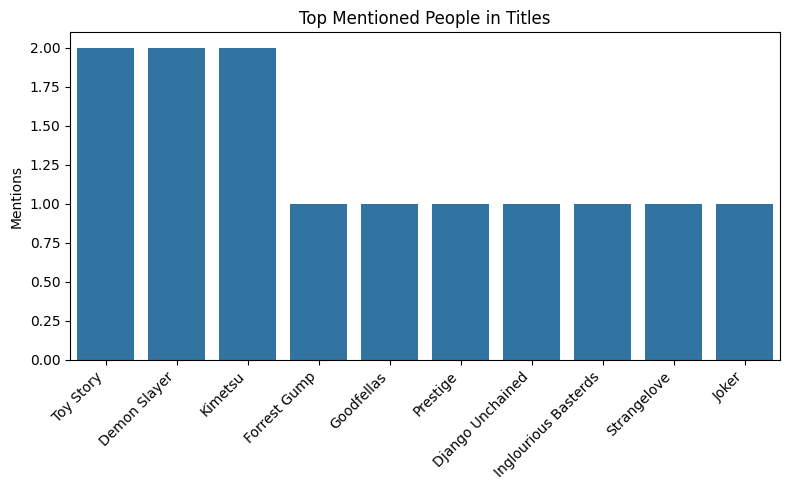


Analysis complete using 'Title' column.


In [ ]:
# movie_ner_analysis.py
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# -------------------------------------------------
# 1. Load Dataset
# -------------------------------------------------
# Example CSV: columns = ['review_id', 'review_text']
df = pd.read_csv("imdb_top_movies.csv")

print("Sample Data:")
print(df.head())

# -------------------------------------------------
# 2. Load spaCy Model
# -------------------------------------------------
# Download model (run this once in terminal if not installed):
# python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

# -------------------------------------------------
# 3. Apply NER to Extract Entities
# -------------------------------------------------
def extract_entities(text):
    # Ensure text is a string before processing
    if pd.isna(text):
        return []
    doc = nlp(str(text))
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

# Apply NER to the 'Title' column
df["entities"] = df["Title"].apply(extract_entities)

print("\nSample Extracted Entities:")
print(df[["Title", "entities"]].head())

# -------------------------------------------------
# 4. Analyze Entity Types
# -------------------------------------------------
# Flatten all entities
all_entities = [ent for movie_entities in df["entities"] for ent in movie_entities]
entity_labels = [label for _, label in all_entities]

# Count most common entity types
entity_counts = Counter(entity_labels)
print("\nEntity Type Frequency:")
for label, count in entity_counts.items():
    print(f"{label}: {count}")

# -------------------------------------------------
# 5. Visualize Most Common Entity Types
# -------------------------------------------------
if entity_counts: # Check if entity_counts is not empty
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(entity_counts.keys()), y=list(entity_counts.values()))
    plt.title("Most Common Entity Types in Movie Titles")
    plt.xlabel("Entity Type")
    plt.ylabel("Count")
    plt.show()
else:
    print("\nNo entities found for visualization.")


# -------------------------------------------------
# 6. Extract and Analyze Movie-Related Entities
# -------------------------------------------------
# Filter entities that are likely to be movie titles or people
# Based on spaCy's 'en_core_web_sm' model, 'WORK_OF_ART' is a common label for titles
movie_titles_entities = [text for text, label in all_entities if label == "WORK_OF_ART"]
people = [text for text, label in all_entities if label == "PERSON"]

top_movies = Counter(movie_titles_entities).most_common(10)
top_people = Counter(people).most_common(10)

print("\nTop Mentioned Movies (from titles):")
if top_movies:
    for movie, count in top_movies:
        print(f"{movie}: {count}")
else:
    print("No movie titles entities found.")

print("\nTop Mentioned People (from titles):")
if top_people:
    for person, count in top_people:
        print(f"{person}: {count}")
else:
    print("No person entities found.")


# -------------------------------------------------
# 7. Visualize Entity Mentions
# -------------------------------------------------
if top_movies:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=[m[0] for m in top_movies], y=[m[1] for m in top_movies])
    plt.xticks(rotation=45, ha="right")
    plt.title("Top Mentioned Movies in Titles")
    plt.ylabel("Mentions")
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()
else:
    print("\nNot enough movie titles entities to visualize.")


if top_people:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=[p[0] for p in top_people], y=[p[1] for p in top_people])
    plt.xticks(rotation=45, ha="right")
    plt.title("Top Mentioned People in Titles")
    plt.ylabel("Mentions")
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()
else:
    print("\nNot enough person entities to visualize.")


# -------------------------------------------------
# 8. Save Results
# -------------------------------------------------
# It might not be meaningful to save results with entities extracted from titles
# as it's not review text. You can uncomment the following line if needed,
# but consider the context.
# df.to_csv("movie_titles_with_entities.csv", index=False)
# print("\n✅ Saved file as 'movie_titles_with_entities.csv'")

print("\nAnalysis complete using 'Title' column.")